In [2]:
import asyncio
from bleak import BleakScanner

async def scan():
    devices = await BleakScanner.discover()
    for d in devices:
        print(d)

await scan()


E4:52:1E:6C:8C:B1: S564e085f74218a15C
55:21:44:DE:59:6D: None
A4:C1:38:BA:74:B3: ihoment_H6195_74B3
77:09:14:52:84:4C: None
51:CD:78:A2:F4:B3: None
EC:A9:07:03:5C:87: None
50:F1:4A:EC:52:6C: GM4535N
98:1B:B5:7E:03:C0: LK00232
B0:E4:5C:AC:E5:0B: None
24:AC:AC:08:43:61: Polar H10 08436133
0A:49:F4:13:6D:61: None


In [1]:
a = [1,2,3,4,5,6]
a[-5:]

[2, 3, 4, 5, 6]

In [ ]:
class HRVRecorder:
    def __init__(self):
        self.rr = []

    def handle_hr(self, sender, data):
        flags = data[0]
        if flags & 0x10:
            for i in range(2, len(data), 2):
                rr = int.from_bytes(data[i:i+2], "little") / 1024
                self.rr.append(rr)
                
    def clear(self):
        self.rr = []

In [ ]:
import asyncio
from bleak import BleakClient

ADDRESS = "24:AC:AC:08:43:61"
HR_CHAR = "00002a37-0000-1000-8000-00805f9b34fb"
async def run(num_seconds):
    async with BleakClient(ADDRESS) as client:
        print("Connected")
        
        await client.start_notify(HR_CHAR, recorder.handle_hr)

        await asyncio.sleep(num_seconds)

recorder = HRVRecorder()
await run(60)
relaxed_rr = recorder.rr
recorder.clear()

Connected
Get Ready for the Next Set
Connected


In [60]:
recorder.rr

[]

In [24]:
from matplotlib import pyplot as plt

(0.5, 1.0)

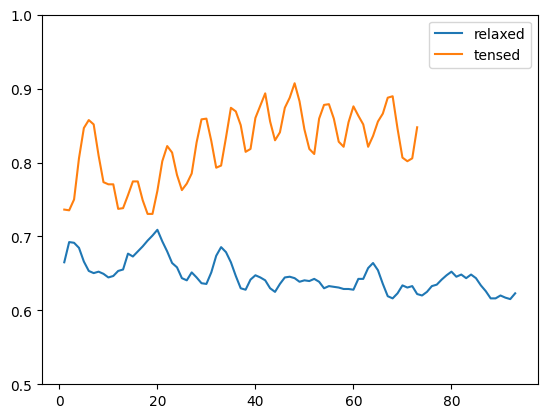

In [66]:
plt.plot(range(1,len(relaxed_rr)+1),relaxed_rr, label="relaxed")
plt.plot(range(1,len(tensed_rr)+1),tensed_rr, label="tensed")
plt.legend()
plt.ylim(bottom=0.5, top=1.0)

In [68]:
import numpy as np

rmssd_array_tensed = []
for i in range(2, len(tensed_rr)):
    window = tensed_rr[i-2:i+1]
    diffs = np.diff(window) * 1000
    rmssd = np.sqrt(np.mean(diffs**2))
    rmssd_array_tensed.append(rmssd)

rmssd_array_relaxed = []
for i in range(2, len(relaxed_rr)):
    window = relaxed_rr[i-2:i+1]
    diffs = np.diff(window) * 1000
    rmssd = np.sqrt(np.mean(diffs**2))
    rmssd_array_relaxed.append(rmssd)

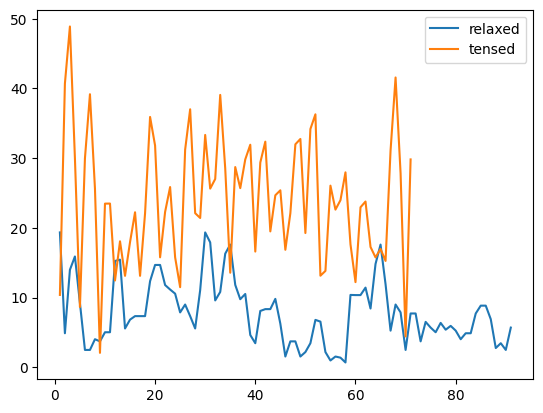

In [69]:
plt.plot(range(1,len(rmssd_array_relaxed)+1),rmssd_array_relaxed, label="relaxed")
plt.plot(range(1,len(rmssd_array_tensed)+1),rmssd_array_tensed, label="tensed")
plt.legend()